[INFO] Judge model : gpt-4o-mini
[INFO] SCORE_DIR   : C:\Users\User\Downloads\학술\9_ai거버넌스_챗봇_ssci\financial_ai_governance\results\scores
[INFO] Baseline records   : 300
[INFO] RAG records        : 300
[INFO] G1~G4 score rows   : 600
[INFO] LLM-as-Judge prompt defined.
  Dimensions: regulatory_accuracy | practical_utility | completeness | clarity | risk_awareness
[RUN] LLM-as-Judge evaluation ...
      Judge model: gpt-4o-mini | Temperature: 0.0
      Total records: 600



LLM-as-Judge:   8%|█████▌                                                             | 50/600 [03:33<34:54,  3.81s/it]

  [Checkpoint  50/600] errors: 0 | avg overall score (last 50): 4.052 | tokens so far: 61,083


LLM-as-Judge:  17%|███████████                                                       | 100/600 [06:33<31:25,  3.77s/it]

  [Checkpoint 100/600] errors: 0 | avg overall score (last 50): 3.984 | tokens so far: 126,222


...

  [Checkpoint 500/600] errors: 0 | avg overall score (last 50): 4.178 | tokens so far: 658,517


LLM-as-Judge:  92%|████████████████████████████████████████████████████████████▌     | 550/600 [32:48<03:06,  3.73s/it]

  [Checkpoint 550/600] errors: 0 | avg overall score (last 50): 4.238 | tokens so far: 727,547


LLM-as-Judge: 100%|██████████████████████████████████████████████████████████████████| 600/600 [35:36<00:00,  3.56s/it]

  [Checkpoint 600/600] errors: 0 | avg overall score (last 50): 4.126 | tokens so far: 799,653

[INFO] LLM-as-Judge complete.
[INFO] Total errors  : 0
[INFO] Total tokens  : 799,653
[INFO] Estimated cost: $0.1199
[SAVE] ../results/scores\scores_llm_as_judge.csv
[INFO] Records saved: 600
  LLM-AS-JUDGE RESULTS — BASELINE vs RAG

[NIST AI RMF]
          Dimension  Baseline   RAG  Δ (RAG−BL)
regulatory_accuracy     3.795 4.015       0.220
  practical_utility     4.270 4.285       0.015
       completeness     3.515 3.805       0.290
            clarity     4.290 4.340       0.050
     risk_awareness     4.320 4.505       0.185
      overall_score     4.018 4.183       0.165

[Korean AI Basic Act]
          Dimension  Baseline   RAG  Δ (RAG−BL)
regulatory_accuracy     3.740 4.285       0.545
  practical_utility     4.080 4.270       0.190
       completeness     3.425 3.910       0.485
            clarity     4.330 4.460       0.130
     risk_awareness     4.150 4.320       0.170
      ove

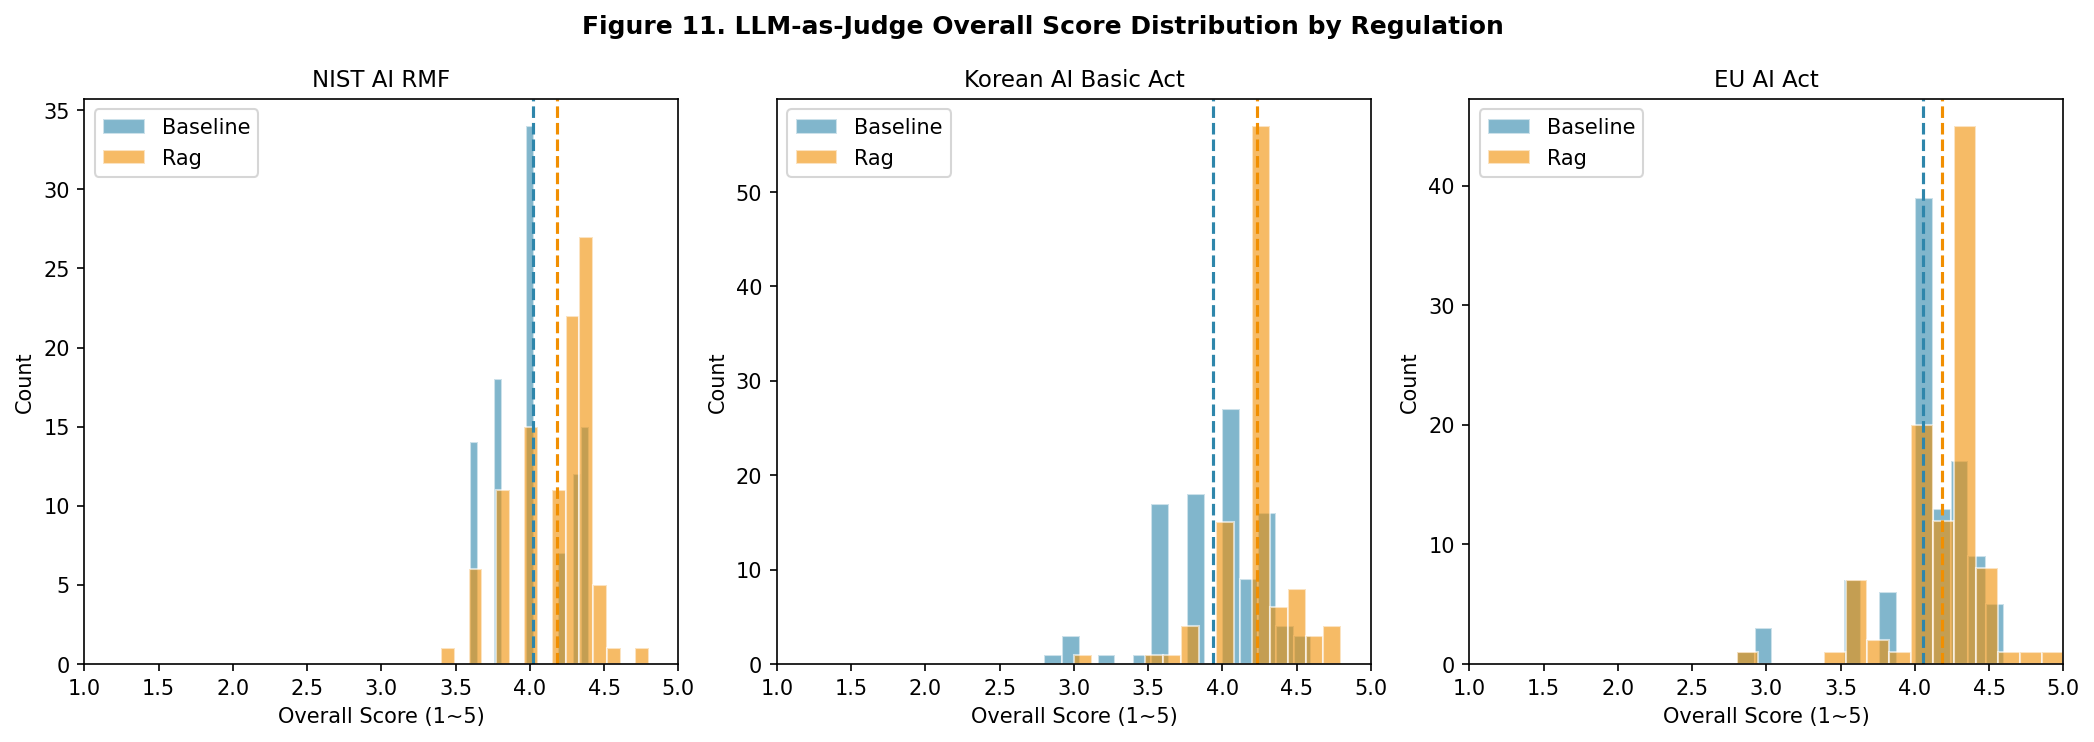

[SAVE] ../results/figures\fig11_llm_judge_distribution.png

✅ Notebook 06 complete — Next: 07_governance_score.ipynb


In [1]:
# %%
# =============================================================================
# 06_llm_as_judge.ipynb
# Financial AI Governance — LLM-as-Judge Quality Evaluation
# Kernel : Python (llm_env)
# Input  : results/responses/responses_baseline.json
#          results/responses/responses_rag.json
#          results/scores/scores_all.csv
# Output : results/scores/scores_llm_as_judge.csv
#          results/tables/table8_llm_judge_results.csv
#          results/figures/fig11_llm_judge_distribution.png
# =============================================================================

# %%
# =============================================================================
# Cell 1. Libraries and Environment Setup
# =============================================================================
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv
from tqdm import tqdm

# Directory paths
RESPONSE_DIR = '../results/responses'
SCORE_DIR    = '../results/scores'
TABLE_DIR    = '../results/tables'
FIGURE_DIR   = '../results/figures'

for d in [SCORE_DIR, TABLE_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

# API setup
load_dotenv()
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
JUDGE_MODEL    = 'gpt-4o-mini'

if not OPENAI_API_KEY:
    raise ValueError("[ERROR] OPENAI_API_KEY not set in .env")

client = OpenAI(api_key=OPENAI_API_KEY)

# Plot style
plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 10,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
})

print(f"[INFO] Judge model : {JUDGE_MODEL}")
print(f"[INFO] SCORE_DIR   : {os.path.abspath(SCORE_DIR)}")


# %%
# =============================================================================
# Cell 2. Load Data
# =============================================================================
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

baseline = load_json(os.path.join(RESPONSE_DIR, 'responses_baseline.json'))
rag      = load_json(os.path.join(RESPONSE_DIR, 'responses_rag.json'))

df_bl  = pd.DataFrame(baseline)
df_rag = pd.DataFrame(rag)
df_all = pd.concat([df_bl, df_rag], ignore_index=True)

df_g_scores = pd.read_csv(os.path.join(SCORE_DIR, 'scores_all.csv'))

print(f"[INFO] Baseline records   : {len(df_bl)}")
print(f"[INFO] RAG records        : {len(df_rag)}")
print(f"[INFO] G1~G4 score rows   : {len(df_g_scores)}")


# %%
# =============================================================================
# Cell 3. LLM-as-Judge Prompt
# =============================================================================
# Single holistic prompt evaluating overall governance quality
# Returns structured JSON with 5 sub-scores and overall score

JUDGE_SYSTEM = """You are an expert AI governance evaluator with deep knowledge of:
- NIST AI Risk Management Framework (AI RMF 1.0)
- EU AI Act (Regulation 2024/1689)
- Korean AI Basic Act (Law No. 21311)

Your task is to evaluate AI governance chatbot responses for financial institution
AI Review Committees. Evaluate responses as a senior compliance expert would."""

JUDGE_PROMPT = """Evaluate the following AI governance chatbot response for quality and
compliance-readiness. Score each dimension from 1.0 to 5.0.

--- QUESTION ---
{question}

--- GROUND TRUTH (Expert Reference) ---
{ground_truth}

--- AI RESPONSE TO EVALUATE ---
{response}

--- REGULATION CONTEXT ---
Regulation: {regulation}
Governance Axis: {governance_axis}
Financial Domain: {financial_domain}

Scoring dimensions (1.0 = very poor, 5.0 = excellent):
1. regulatory_accuracy   : Correctness of regulatory citations and interpretations
2. practical_utility     : Usefulness for an AI Review Committee making real decisions
3. completeness          : Coverage of key governance requirements vs ground truth
4. clarity               : Clarity and structure of the response
5. risk_awareness        : Identification of risks and recommendation of human oversight

Respond ONLY in valid JSON format (no markdown):
{{
  "regulatory_accuracy": <1.0-5.0>,
  "practical_utility"  : <1.0-5.0>,
  "completeness"       : <1.0-5.0>,
  "clarity"            : <1.0-5.0>,
  "risk_awareness"     : <1.0-5.0>,
  "overall_score"      : <1.0-5.0>,
  "strengths"          : "<one sentence>",
  "weaknesses"         : "<one sentence>"
}}"""

print("[INFO] LLM-as-Judge prompt defined.")
print("  Dimensions: regulatory_accuracy | practical_utility | completeness | clarity | risk_awareness")


# %%
# =============================================================================
# Cell 4. Judge Function
# =============================================================================
REG_LABEL = {
    'NIST_AI_RMF'    : 'NIST AI RMF',
    'KR_AI_BASIC_ACT': 'Korean AI Basic Act',
    'EU_AI_ACT'      : 'EU AI Act',
}

def judge_response(row: pd.Series) -> dict:
    """
    Run LLM-as-Judge evaluation on a single response row.

    Returns:
        dict with 5 sub-scores, overall_score, strengths, weaknesses
    """
    prompt = JUDGE_PROMPT.format(
        question        = row['question'],
        ground_truth    = row['ground_truth'],
        response        = row['response'],
        regulation      = REG_LABEL.get(row['regulation'], row['regulation']),
        governance_axis = row['governance_axis'],
        financial_domain= row['financial_domain'],
    )
    try:
        res = client.chat.completions.create(
            model      = JUDGE_MODEL,
            temperature= 0.0,
            max_tokens = 300,
            messages   = [
                {'role': 'system', 'content': JUDGE_SYSTEM},
                {'role': 'user',   'content': prompt},
            ]
        )
        raw = res.choices[0].message.content.strip()
        raw = raw.replace('```json', '').replace('```', '').strip()
        parsed = json.loads(raw)
        return {
            'regulatory_accuracy': float(parsed.get('regulatory_accuracy', -1)),
            'practical_utility'  : float(parsed.get('practical_utility',   -1)),
            'completeness'       : float(parsed.get('completeness',         -1)),
            'clarity'            : float(parsed.get('clarity',              -1)),
            'risk_awareness'     : float(parsed.get('risk_awareness',       -1)),
            'overall_score'      : float(parsed.get('overall_score',        -1)),
            'strengths'          : str(parsed.get('strengths',  '')),
            'weaknesses'         : str(parsed.get('weaknesses', '')),
            'total_tokens'       : res.usage.total_tokens,
        }
    except Exception as e:
        return {
            'regulatory_accuracy': -1, 'practical_utility': -1,
            'completeness'       : -1, 'clarity'          : -1,
            'risk_awareness'     : -1, 'overall_score'    : -1,
            'strengths'          : '', 'weaknesses'       : f'[ERROR] {str(e)}',
            'total_tokens'       : 0,
        }


# %%
# =============================================================================
# Cell 5. Run LLM-as-Judge (Baseline + RAG, Full 600 records)
# =============================================================================
print("[RUN] LLM-as-Judge evaluation ...")
print(f"      Judge model: {JUDGE_MODEL} | Temperature: 0.0")
print(f"      Total records: {len(df_all)}\n")

judge_results = []
total_tokens  = 0
total_errors  = 0

for i, row in tqdm(df_all.iterrows(), total=len(df_all), desc='LLM-as-Judge'):
    result = judge_response(row)

    judge_results.append({
        # Identifiers
        'id'              : row['id'],
        'condition'       : row['condition'],
        'regulation'      : row['regulation'],
        'difficulty'      : row['difficulty'],
        'financial_domain': row['financial_domain'],
        'risk_level'      : row['risk_level'],
        'governance_axis' : row['governance_axis'],
        # Scores
        'regulatory_accuracy': result['regulatory_accuracy'],
        'practical_utility'  : result['practical_utility'],
        'completeness'       : result['completeness'],
        'clarity'            : result['clarity'],
        'risk_awareness'     : result['risk_awareness'],
        'overall_score'      : result['overall_score'],
        # Qualitative
        'strengths'          : result['strengths'],
        'weaknesses'         : result['weaknesses'],
        'total_tokens'       : result['total_tokens'],
    })

    total_tokens += result['total_tokens']
    if result['overall_score'] < 0:
        total_errors += 1
    time.sleep(0.2)

    # Checkpoint every 50 records
    if (i + 1) % 50 == 0:
        recent   = judge_results[-50:]
        valid    = [r for r in recent if r['overall_score'] > 0]
        avg_score= np.mean([r['overall_score'] for r in valid]) if valid else 0
        print(f"  [Checkpoint {i+1:3d}/600] errors: {total_errors} | "
              f"avg overall score (last 50): {avg_score:.3f} | "
              f"tokens so far: {total_tokens:,}")

print(f"\n[INFO] LLM-as-Judge complete.")
print(f"[INFO] Total errors  : {total_errors}")
print(f"[INFO] Total tokens  : {total_tokens:,}")
print(f"[INFO] Estimated cost: ${total_tokens * 0.00000015:.4f}")


# %%
# =============================================================================
# Cell 6. Save Results
# =============================================================================
df_judge = pd.DataFrame(judge_results)

out_judge = os.path.join(SCORE_DIR, 'scores_llm_as_judge.csv')
df_judge.to_csv(out_judge, index=False, encoding='utf-8-sig')
print(f"[SAVE] {out_judge}")
print(f"[INFO] Records saved: {len(df_judge)}")


# %%
# =============================================================================
# Cell 7. Summary — Baseline vs RAG by Regulation
# =============================================================================
DIMS = ['regulatory_accuracy', 'practical_utility',
        'completeness', 'clarity', 'risk_awareness', 'overall_score']

print("=" * 65)
print("  LLM-AS-JUDGE RESULTS — BASELINE vs RAG")
print("=" * 65)

for reg_key, reg_label in REG_LABEL.items():
    print(f"\n[{reg_label}]")
    sub = df_judge[df_judge['regulation'] == reg_key]
    bl  = sub[sub['condition'] == 'baseline']
    rag = sub[sub['condition'] == 'rag']

    summary = pd.DataFrame({
        'Dimension': DIMS,
        'Baseline' : [bl[d].mean() for d in DIMS],
        'RAG'      : [rag[d].mean() for d in DIMS],
    })
    summary['Δ (RAG−BL)'] = summary['RAG'] - summary['Baseline']
    print(summary.round(3).to_string(index=False))


# %%
# =============================================================================
# Cell 8. Table 8 — LLM-as-Judge Results (for Paper)
# =============================================================================
rows = []
for reg_key, reg_label in REG_LABEL.items():
    for cond in ['baseline', 'rag']:
        sub = df_judge[
            (df_judge['regulation'] == reg_key) &
            (df_judge['condition']  == cond)
        ]
        valid = sub[sub['overall_score'] > 0]
        if len(valid) == 0:
            continue
        row = {
            'Condition'           : cond.capitalize(),
            'Regulation'          : reg_label,
            'N'                   : len(valid),
            'Regulatory Accuracy' : round(valid['regulatory_accuracy'].mean(), 3),
            'Practical Utility'   : round(valid['practical_utility'].mean(),   3),
            'Completeness'        : round(valid['completeness'].mean(),         3),
            'Clarity'             : round(valid['clarity'].mean(),              3),
            'Risk Awareness'      : round(valid['risk_awareness'].mean(),       3),
            'Overall Score'       : round(valid['overall_score'].mean(),        3),
        }
        rows.append(row)

table8 = pd.DataFrame(rows)
out_t8 = os.path.join(TABLE_DIR, 'table8_llm_judge_results.csv')
table8.to_csv(out_t8, index=False, encoding='utf-8-sig')

print("[Table 8] LLM-as-Judge Quality Evaluation")
print(table8.to_string(index=False))
print(f"\n[SAVE] {out_t8}")


# %%
# =============================================================================
# Cell 9. Figure 11 — Score Distribution (for Paper)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Figure 11. LLM-as-Judge Overall Score Distribution by Regulation',
    fontsize=12, fontweight='bold'
)

colors = {'baseline': '#2E86AB', 'rag': '#F18F01'}

for ax, (reg_key, reg_label) in zip(axes, REG_LABEL.items()):
    sub = df_judge[df_judge['regulation'] == reg_key]
    for cond, color in colors.items():
        data = sub[sub['condition'] == cond]['overall_score']
        data = data[data > 0]
        ax.hist(data, bins=15, alpha=0.6, color=color,
                label=cond.capitalize(), edgecolor='white')

    ax.set_title(reg_label)
    ax.set_xlabel('Overall Score (1~5)')
    ax.set_ylabel('Count')
    ax.set_xlim(1, 5)
    ax.legend()

    # Annotate means
    for cond, color in colors.items():
        mean_val = sub[sub['condition'] == cond]['overall_score'].mean()
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5,
                   label=f'{cond.capitalize()} mean={mean_val:.2f}')

plt.tight_layout()
out_fig = os.path.join(FIGURE_DIR, 'fig11_llm_judge_distribution.png')
fig.savefig(out_fig, bbox_inches='tight', dpi=150)
plt.show()
print(f"[SAVE] {out_fig}")

print(f"\n✅ Notebook 06 complete — Next: 07_governance_score.ipynb")